# Notebook Sanity Check - Análisis de **un episodio**
- Unidad narrativa: **intervalo de decisión** → cadena causal (dinámica → control → métricas/reward → decisión RL → update).
- Fuente: **JSON en chunks de episodios**.

## Caja 0 - Imports + settings

In [1]:
from pathlib import Path
import json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Path del directorio de resultados
RUN_DIR = Path(r".../results_history_CartPole/cart_pole/20260223_0100")


## Caja 1 - Helpers mínimos

In [2]:
def extract_episode_id(ep):
    if isinstance(ep, dict) and 'episode_id' in ep:
        try:
            return int(ep['episode_id'])
        except Exception:
            return None
    if isinstance(ep, dict) and isinstance(ep.get('episode_data'), dict) and 'episode_id' in ep['episode_data']:
        try:
            return int(ep['episode_data']['episode_id'])
        except Exception:
            return None
    return None


def load_json(path: Path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def discover_chunk_files(run_dir: Path):
    # Heurística simple: toma *.json y excluye metadata/config por nombre
    files = []
    for p in sorted(run_dir.resolve().rglob('*.json')):
        name = p.name.lower()
        if 'metadata' in name:
            continue
        if 'config' in name:
            continue
        files.append(p)
    return files


#def build_episode_index(chunk_paths):                  ### SE ELIMINA YA QUE ES MUY COSTOSO ESTE MÉTODO, RESUELTO MANUAL
#    # episode_id -> (chunk_path, index_in_chunk)
#    idx = {}
#    for cp in chunk_paths:
#        try:
#            obj = load_json(cp)
#        except Exception:
#            continue
#        episodes = list(iter_episode_dicts(obj))
#        for i, ep in enumerate(episodes):
#            eid = extract_episode_id(ep)
#            if eid is None:
#                continue
#            if eid not in idx:
#                idx[eid] = (cp, i)
#    return idx

def find_key_by_value(episode_index: dict, episode_id: int):
    for file_name, ep_groups in episode_index.items():
        if episode_id in ep_groups:
            return file_name, ep_groups.index(episode_id)
    return None, None
        
def load_episode_from_index(episode_index: dict, episode_id: int):
    dir_file, idx_episode_id = find_key_by_value(episode_index, episode_id)
    episodes = list(load_json(dir_file))
    ep_data = episodes[idx_episode_id]
    return ep_data, dir_file


def list_series_keys(d):
    return [k for k, v in d.items() if isinstance(k, str) and isinstance(v, list)]


def build_df(series_dict):
    keys = list_series_keys(series_dict)
    if not keys:
        return pd.DataFrame()

    lists = {k: series_dict[k] for k in keys if isinstance(series_dict.get(k), list)}
    if not lists:
        return pd.DataFrame()

    n = max(map(len, lists.values()))
    data = {k: v + [np.nan] * (n - len(v)) for k, v in lists.items()}
    return pd.DataFrame(data)

def absmax(s):
    if s is None or len(s) == 0:
        return None
    a = np.abs(pd.to_numeric(pd.Series(s), errors='coerce')).dropna()
    return float(a.max()) if len(a) else None

def add_interval_aggs(interval_df, step_df, agg_map,
                      start_col='interval_start_step_idx',
                      end_col='interval_end_step_idx'):
    out = interval_df.copy()

    for col, spec in agg_map.items():
        # spec puede ser 'mean' o ('mean', 'nombre_custom')
        agg, new_name = (spec, f'{col}_{spec}') if isinstance(spec, str) else spec

        vals = []
        for a, b in zip(out[start_col], out[end_col]):
            s = step_df.loc[a:b, col]
            if agg == 'bool_mean':
                vals.append(float(s.astype(bool).mean()))
            else:
                vals.append(float(getattr(s, agg)()))
        out[new_name] = vals

    return out


## Caja 2 - Discover chunks + index de episodios

In [3]:
chunk_files = discover_chunk_files(RUN_DIR)
print(f'chunks encontrados: {len(chunk_files)}')
chunk_files[:5]


chunks encontrados: 50


[WindowsPath('C:/Users/davor/Escritorio/DOCTORADO/Tesis/RL_5_SimpleSystemSimulator/results_history_CartPole/cart_pole/20260223_0100/episodes_chunks_0000.json'),
 WindowsPath('C:/Users/davor/Escritorio/DOCTORADO/Tesis/RL_5_SimpleSystemSimulator/results_history_CartPole/cart_pole/20260223_0100/episodes_chunks_0001.json'),
 WindowsPath('C:/Users/davor/Escritorio/DOCTORADO/Tesis/RL_5_SimpleSystemSimulator/results_history_CartPole/cart_pole/20260223_0100/episodes_chunks_0002.json'),
 WindowsPath('C:/Users/davor/Escritorio/DOCTORADO/Tesis/RL_5_SimpleSystemSimulator/results_history_CartPole/cart_pole/20260223_0100/episodes_chunks_0003.json'),
 WindowsPath('C:/Users/davor/Escritorio/DOCTORADO/Tesis/RL_5_SimpleSystemSimulator/results_history_CartPole/cart_pole/20260223_0100/episodes_chunks_0004.json')]

In [4]:
n_episodes = 5000
ep_for_file = int(n_episodes/len(chunk_files))
episode_index = {}
idx_i = 0
idx_f = 0
id_dir_file = 0
for cf in chunk_files:
    idx_f += ep_for_file
    episode_index[cf] = list(range(idx_i, idx_f))
    idx_i = idx_f
    id_dir_file += 1
list(episode_index.items())[-2:]

[(WindowsPath('C:/Users/davor/Escritorio/DOCTORADO/Tesis/RL_5_SimpleSystemSimulator/results_history_CartPole/cart_pole/20260223_0100/episodes_chunks_0048.json'),
  [4800,
   4801,
   4802,
   4803,
   4804,
   4805,
   4806,
   4807,
   4808,
   4809,
   4810,
   4811,
   4812,
   4813,
   4814,
   4815,
   4816,
   4817,
   4818,
   4819,
   4820,
   4821,
   4822,
   4823,
   4824,
   4825,
   4826,
   4827,
   4828,
   4829,
   4830,
   4831,
   4832,
   4833,
   4834,
   4835,
   4836,
   4837,
   4838,
   4839,
   4840,
   4841,
   4842,
   4843,
   4844,
   4845,
   4846,
   4847,
   4848,
   4849,
   4850,
   4851,
   4852,
   4853,
   4854,
   4855,
   4856,
   4857,
   4858,
   4859,
   4860,
   4861,
   4862,
   4863,
   4864,
   4865,
   4866,
   4867,
   4868,
   4869,
   4870,
   4871,
   4872,
   4873,
   4874,
   4875,
   4876,
   4877,
   4878,
   4879,
   4880,
   4881,
   4882,
   4883,
   4884,
   4885,
   4886,
   4887,
   4888,
   4889,
   4890,
   4891,
   4892,
 

## Caja 3 - Cargar episodio

In [5]:
EPISODE_ID = 4500

In [6]:
episode, source_chunk = load_episode_from_index(episode_index, EPISODE_ID)
print('source_chunk:', source_chunk)
print('episode keys:', list(episode.keys()))

step_data = episode.get('step_data', {})
interval_data = episode.get('interval_data', {})
end_data = episode.get('end_episode_data', {})

print('step_data keys:', len(step_data))
print('interval_data keys:', len(interval_data))
print('end_data keys:', len(end_data))


source_chunk: C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5_SimpleSystemSimulator\results_history_CartPole\cart_pole\20260223_0100\episodes_chunks_0045.json
episode keys: ['episode_id', 'step_data', 'interval_data', 'end_episode_data']
step_data keys: 37
interval_data keys: 32
end_data keys: 8


## Caja 4 - DataFrames step/interval

In [7]:
step_df = build_df(step_data)
interval_df = build_df(interval_data)

print('step_df shape:', step_df.shape)
step_df.head(3)


step_df shape: (1802, 36)


,t_sec,cart_position_raw,cart_velocity_raw,pendulum_angle_raw,pendulum_velocity_raw,cart_position_norm,cart_velocity_norm,pendulum_angle_norm,pendulum_velocity_norm,cart_force,...,u_eff_pendulum_angle,u_eff_cart_position,delta_u_eff_pendulum_angle,delta_u_eff_cart_position,kp_pendulum_angle,kp_cart_position,ki_pendulum_angle,ki_cart_position,kd_pendulum_angle,kd_cart_position
0,0.000,0.000000e+00,0.000000,0.157000,0.000000,0.000000e+00,0.000000,0.149924,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.00000,1.00,1.00,1.00,1.00,1.00,1.00
1,0.001,4.764804e-07,0.000953,0.157000,0.000593,2.382402e-07,0.000119,0.149924,0.000148,6.303088,...,0.157577,0.00000,0.157577,0.00000,1.05,0.95,1.05,1.05,1.05,1.05
2,0.002,1.906734e-06,0.001908,0.157001,0.001184,9.533671e-07,0.000238,0.149925,0.000296,6.311266,...,0.158032,-0.00025,0.000455,-0.00025,1.05,0.95,1.05,1.05,1.05,1.05


In [8]:
step_df.columns

Index(['t_sec', 'cart_position_raw', 'cart_velocity_raw', 'pendulum_angle_raw',
       'pendulum_velocity_raw', 'cart_position_norm', 'cart_velocity_norm',
       'pendulum_angle_norm', 'pendulum_velocity_norm', 'cart_force',
       'u_total', 'u_total_raw', 'is_saturated_global', 'delta_u_total',
       'error_pendulum_angle', 'error_cart_position',
       'delta_error_pendulum_angle', 'delta_error_cart_position',
       'derivative_error_pendulum_angle', 'derivative_error_cart_position',
       'integral_error_pendulum_angle', 'integral_error_cart_position',
       'control_action_pendulum_angle', 'control_action_cart_position',
       'delta_control_action_pendulum_angle',
       'delta_control_action_cart_position', 'u_eff_pendulum_angle',
       'u_eff_cart_position', 'delta_u_eff_pendulum_angle',
       'delta_u_eff_cart_position', 'kp_pendulum_angle', 'kp_cart_position',
       'ki_pendulum_angle', 'ki_cart_position', 'kd_pendulum_angle',
       'kd_cart_position'],
      dtype=

In [9]:
print('interval_df shape:', interval_df.shape)
interval_df.head(5)


interval_df shape: (91, 31)


,interval_id,interval_start_step_idx,interval_end_step_idx,interval_t_start_sec,interval_n_steps,L_e_pendulum_angle,L_e_cart_position,L_edot_pendulum_angle,L_edot_cart_position,L_delta_u_pendulum_angle,...,action_ki_cart_position,action_kd_cart_position,global_interval_reward,reward_kp_pendulum_angle,reward_ki_pendulum_angle,reward_kd_pendulum_angle,reward_kp_cart_position,reward_ki_cart_position,reward_kd_cart_position,extra_bonus_band_cart_position
0,0,0,19,0.00,20,0.022487,1.627680e-09,0.000004,0.000003,0.000311,...,2,2,-0.018022,-0.049840,-0.049840,-0.049840,-0.000033,-0.000033,-0.000033,NaN
1,1,20,39,0.02,20,0.022551,5.618317e-08,0.000027,0.000024,0.000001,...,2,2,-0.018046,-0.057560,-0.057560,-0.057560,-0.000295,-0.000295,-0.000295,NaN
2,2,40,59,0.04,20,0.022671,4.106807e-07,0.000065,0.000073,0.000001,...,2,2,-0.018151,-0.066362,-0.066362,-0.066362,-0.000969,-0.000969,-0.000969,NaN
3,3,60,79,0.06,20,0.022841,1.608630e-06,0.000113,0.000152,0.000001,...,2,2,-0.018301,-0.076484,-0.076484,-0.076484,-0.002218,-0.002218,-0.002218,NaN
4,4,80,99,0.08,20,0.023057,4.537857e-06,0.000169,0.000265,0.000001,...,2,2,-0.018493,-0.087218,-0.087218,-0.087218,-0.004211,-0.004211,-0.004211,NaN


In [10]:
interval_df.columns

Index(['interval_id', 'interval_start_step_idx', 'interval_end_step_idx',
       'interval_t_start_sec', 'interval_n_steps', 'L_e_pendulum_angle',
       'L_e_cart_position', 'L_edot_pendulum_angle', 'L_edot_cart_position',
       'L_delta_u_pendulum_angle', 'L_delta_u_cart_position',
       'error_pendulum_angle_mean', 'error_cart_position_mean',
       'derivative_error_pendulum_angle_mean',
       'derivative_error_cart_position_mean',
       'delta_u_eff_pendulum_angle_mean', 'delta_u_eff_cart_position_mean',
       'action_kp_pendulum_angle', 'action_ki_pendulum_angle',
       'action_kd_pendulum_angle', 'action_kp_cart_position',
       'action_ki_cart_position', 'action_kd_cart_position',
       'global_interval_reward', 'reward_kp_pendulum_angle',
       'reward_ki_pendulum_angle', 'reward_kd_pendulum_angle',
       'reward_kp_cart_position', 'reward_ki_cart_position',
       'reward_kd_cart_position', 'extra_bonus_band_cart_position'],
      dtype='object')

## Caja 5 - Ficha del episodio

In [11]:
n_steps = len(step_df) if len(step_df) else int(step_data.get('n_step', 0) or 0)
n_intervals = len(interval_df) if len(interval_df) else int(interval_data.get('n_interval', 0) or 0)

sat_prp = float(step_df['is_saturated_global'].astype(bool).mean())

card = {
    'episode_id': EPISODE_ID,
    'n_steps': n_steps,
    'n_intervals': n_intervals,
    'pendulum_angle_mean': float(step_df['pendulum_angle_raw'].mean()),
    'pendulum_angle_min': float(step_df['pendulum_angle_raw'].min()),
    'pendulum_angle_max': float(step_df['pendulum_angle_raw'].max()),
    'cart_position_mean': float(step_df['cart_position_raw'].mean()),
    'cart_position_min': float(step_df['cart_position_raw'].min()),
    'cart_position_max': float(step_df['cart_position_raw'].max()),
    'u_total_mean': float(step_df['u_total'].mean()),
    'u_total_min': float(step_df['u_total'].min()),
    'u_total_max': float(step_df['u_total'].max()),
    'sat_prp_steps': sat_prp,
    'reward_sum_kp_pendulum_angle': float(pd.to_numeric(interval_df['reward_kp_pendulum_angle'], errors='coerce').fillna(0).sum()),
    'reward_mean_kp_pendulum_angle': float(pd.to_numeric(interval_df['reward_kp_pendulum_angle'], errors='coerce').fillna(0).mean()),
    'reward_sum_ki_pendulum_angle': float(pd.to_numeric(interval_df['reward_ki_pendulum_angle'], errors='coerce').fillna(0).sum()),
    'reward_mean_ki_pendulum_angle': float(pd.to_numeric(interval_df['reward_ki_pendulum_angle'], errors='coerce').fillna(0).mean()),
    'reward_sum_kd_pendulum_angle': float(pd.to_numeric(interval_df['reward_kd_pendulum_angle'], errors='coerce').fillna(0).sum()),
    'reward_mean_kd_pendulum_angle': float(pd.to_numeric(interval_df['reward_kd_pendulum_angle'], errors='coerce').fillna(0).mean()),
    'reward_sum_kp_cart_position': float(pd.to_numeric(interval_df['reward_kp_cart_position'], errors='coerce').fillna(0).sum()),
    'reward_mean_kp_cart_position': float(pd.to_numeric(interval_df['reward_kp_cart_position'], errors='coerce').fillna(0).mean()),
    'reward_sum_ki_cart_position': float(pd.to_numeric(interval_df['reward_ki_cart_position'], errors='coerce').fillna(0).sum()),
    'reward_mean_ki_cart_position': float(pd.to_numeric(interval_df['reward_ki_cart_position'], errors='coerce').fillna(0).mean()),
    'reward_sum_kd_cart_position': float(pd.to_numeric(interval_df['reward_kd_cart_position'], errors='coerce').fillna(0).sum()),
    'reward_mean_kd_cart_position': float(pd.to_numeric(interval_df['reward_kd_cart_position'], errors='coerce').fillna(0).mean()),
    'reward_sum_intervals': float(pd.to_numeric(interval_df['global_interval_reward'], errors='coerce').fillna(0).sum()),
}
card


{'episode_id': 4500,
 'n_steps': 1802,
 'n_intervals': 91,
 'pendulum_angle_mean': 0.394760500649115,
 'pendulum_angle_min': 0.15700000000000003,
 'pendulum_angle_max': 1.0481554525931598,
 'cart_position_mean': 0.9450627222494908,
 'cart_position_min': 0.0,
 'cart_position_max': 3.4740954723997604,
 'u_total_mean': 0.48929737303628446,
 'u_total_min': 0.0,
 'u_total_max': 1.0,
 'sat_prp_steps': 0.17369589345172032,
 'reward_sum_kp_pendulum_angle': -94.9939344577231,
 'reward_mean_kp_pendulum_angle': -1.0438893896453088,
 'reward_sum_ki_pendulum_angle': -94.9939344577231,
 'reward_mean_ki_pendulum_angle': -1.0438893896453088,
 'reward_sum_kd_pendulum_angle': -94.9939344577231,
 'reward_mean_kd_pendulum_angle': -1.0438893896453088,
 'reward_sum_kp_cart_position': -82.77126420820352,
 'reward_mean_kp_cart_position': -0.9095743319582804,
 'reward_sum_ki_cart_position': -82.77126420820352,
 'reward_mean_ki_cart_position': -0.9095743319582804,
 'reward_sum_kd_cart_position': -82.77126420820

In [12]:
end_data

{'end_terminated': True,
 'end_termination_reason': 'limit_exceeded',
 'accumulated_band_bonus': 0.0,
 'goal_bonus': 0.0,
 'total_reward': -38.913165044290636,
 'total_agent_decisions': 91,
 'epsilon': 0.01,
 'learning_rate': 0.01}

## Caja 6 - Timeline del episodio (por intervalos)

In [ ]:
cols = [
    'interval_id',
    'interval_start_step_idx',
    'interval_end_step_idx',
    'interval_n_steps',
    'global_interval_reward',
]
interval_timeline_df = interval_df[cols].copy()

agg_map = {
    'pendulum_angle_raw': ('mean', 'pendulum_angle_mean'),
    'pendulum_velocity_raw': ('mean', 'pendulum_velocity_mean'),
    'cart_position_raw': ('mean', 'cart_position_mean'),
    'cart_velocity_raw': ('mean', 'cart_velocity_mean'),
    'cart_force': ('mean', 'cart_force_mean'),

    'kp_pendulum_angle': ('mean', 'kp_pendulum_angle_mean'),
    'ki_pendulum_angle': ('mean', 'ki_pendulum_angle_mean'),
    'kd_pendulum_angle': ('mean', 'kd_pendulum_angle_mean'),
    'kp_cart_position': ('mean', 'kp_cart_position_mean'),
    'ki_cart_position': ('mean', 'ki_cart_position_mean'),
    'kd_cart_position': ('mean', 'kd_cart_position_mean'),

    'control_action_pendulum_angle': ('mean', 'u_calc_pendulum_mean'),
    'error_pendulum_angle': ('mean', 'e_pendulum_mean'),
    'derivative_error_pendulum_angle': ('mean', 'edot_pendulum_mean'),
    'integral_error_pendulum_angle': ('mean', 'eint_pendulum_mean'),

    'control_action_cart_position': ('mean', 'u_calc_cart_mean'),
    'error_cart_position': ('mean', 'e_cart_mean'),
    'derivative_error_cart_position': ('mean', 'edot_cart_mean'),
    'integral_error_cart_position': ('mean', 'eint_cart_mean'),

    'is_saturated_global': ('bool_mean', 'sat_prp_interval'),

    'u_total': ('mean', 'u_total_mean'),
    'delta_u_eff_pendulum_angle': ('mean', 'delta_u_eff_pendulum_mean'),
    'delta_u_eff_cart_position': ('mean', 'delta_u_eff_cart_mean'),

    'error_pendulum_angle_mean_squared': ('mean', 'error_pendulum_angle_mean_squared'), 
    'error_cart_position_mean_squared': ('mean', 'error_cart_position_mean_squared'),
    'derivative_error_pendulum_angle_mean_squared': ('mean', 'derivative_error_pendulum_angle_mean_squared'),
    'derivative_error_cart_position_mean_squared': ('mean', 'derivative_error_cart_position_mean_squared'),
    'delta_u_eff_pendulum_angle_mean_squared': ('mean', 'delta_u_eff_pendulum_angle_mean_squared'), 
    'delta_u_eff_cart_position_mean_squared': ('mean', 'delta_u_eff_cart_position_mean_squared'),
}
interval_timeline_df = add_interval_aggs(interval_timeline_df, step_df, agg_map)

end_cols_add = [
    'L_e_pendulum_angle', 'L_edot_pendulum_angle', 'L_delta_u_pendulum_angle',
    'L_e_cart_position', 'L_edot_cart_position','L_delta_u_cart_position',
    'reward_kp_pendulum_angle', 'reward_ki_pendulum_angle', 'reward_kd_pendulum_angle',
    'reward_kp_cart_position', 'reward_ki_cart_position', 'reward_kd_cart_position'
]
interval_timeline_df = interval_timeline_df.join(interval_df[end_cols_add])

interval_timeline_df

KeyError: 'error_pendulum_angle_mean'

In [26]:
interval_timeline_df.columns

Index(['interval_id', 'interval_start_step_idx', 'interval_end_step_idx',
       'interval_n_steps', 'global_interval_reward', 'pendulum_angle_mean',
       'pendulum_velocity_mean', 'cart_position_mean', 'cart_velocity_mean',
       'cart_force_mean', 'kp_pendulum_angle_mean', 'ki_pendulum_angle_mean',
       'kd_pendulum_angle_mean', 'kp_cart_position_mean',
       'ki_cart_position_mean', 'kd_cart_position_mean',
       'u_calc_pendulum_mean', 'e_pendulum_mean', 'edot_pendulum_mean',
       'eint_pendulum_mean', 'u_calc_cart_mean', 'e_cart_mean',
       'edot_cart_mean', 'eint_cart_mean', 'sat_prp_interval', 'u_total_mean',
       'delta_u_eff_pendulum_mean', 'delta_u_eff_cart_mean',
       'L_e_pendulum_angle', 'L_edot_pendulum_angle',
       'L_delta_u_pendulum_angle', 'L_e_cart_position', 'L_edot_cart_position',
       'L_delta_u_cart_position', 'reward_kp_pendulum_angle',
       'reward_ki_pendulum_angle', 'reward_kd_pendulum_angle',
       'reward_kp_cart_position', 'reward_ki_

In [ ]:
dynamic_interval_df = interval_timeline_df.iloc[:,16:20]
#pd.plotting.scatter_matrix(dynamic_interval_df, figsize=(10,6));

In [ ]:
dynamic_interval_df = interval_timeline_df.iloc[:,20:24]
#pd.plotting.scatter_matrix(dynamic_interval_df, figsize=(10,6));

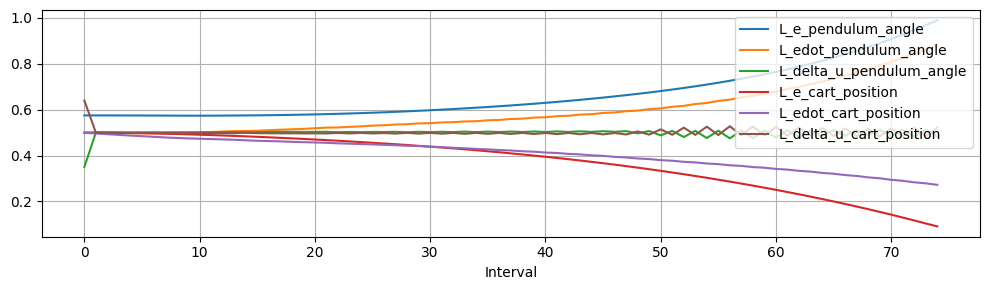

In [27]:
y_cols = ['L_e_pendulum_angle', 'L_edot_pendulum_angle','L_delta_u_pendulum_angle', 
          'L_e_cart_position', 'L_edot_cart_position','L_delta_u_cart_position']

x = interval_timeline_df['interval_id'].to_numpy()
ax = interval_timeline_df.plot(x='interval_id', y=y_cols, figsize=(10, 3), grid=True)

ax.set_xlabel('Interval')
plt.tight_layout()
plt.show()

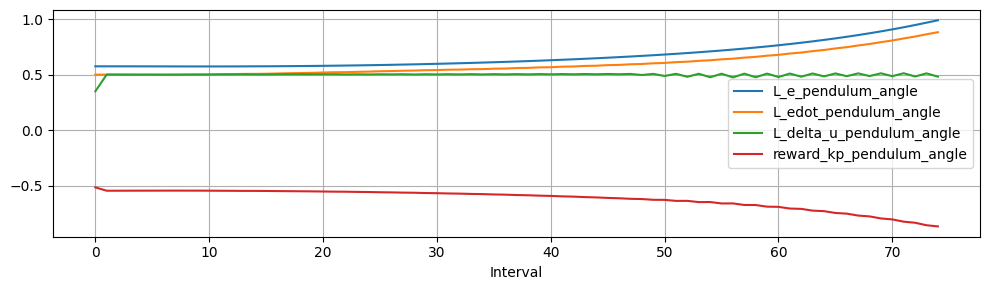

In [28]:
y_cols = ['L_e_pendulum_angle', 'L_edot_pendulum_angle','L_delta_u_pendulum_angle', 'reward_kp_pendulum_angle']

x = interval_timeline_df['interval_id'].to_numpy()
ax = interval_timeline_df.plot(x='interval_id', y=y_cols, figsize=(10, 3), grid=True)

ax.set_xlabel('Interval')
plt.tight_layout()
plt.show()

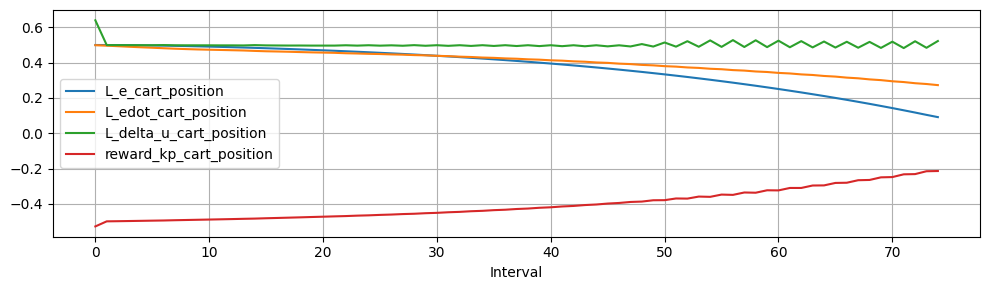

In [29]:
y_cols = ['L_e_cart_position', 'L_edot_cart_position','L_delta_u_cart_position', 'reward_kp_cart_position']

x = interval_timeline_df['interval_id'].to_numpy()
ax = interval_timeline_df.plot(x='interval_id', y=y_cols, figsize=(10, 3), grid=True)

ax.set_xlabel('Interval')
plt.tight_layout()
plt.show()

## Caja 7 - Timeline del episodio (por step)

In [30]:
def plot_many_columns(
    df, cols, colors, styles, alphas,
    col_names=None,
    title="Análisis", figsize=(14, 5),
    interval_lines=interval_df['interval_end_step_idx'],
    x_col=None,              # None => steps, 't_sec' => tiempo (s)
    y_lim=None,
):
    """
    Genera un gráfico multi-eje para análisis de señales de simulación.
    """
    x_step = np.arange(len(df)) if x_col is None else df[x_col].to_numpy()

    label_size = 16
    tick_size = 14
    legend_size = 10

    if col_names is None:
        col_names = cols
    col_names = (list(col_names) + list(cols))[:len(cols)]

    fig, ax_main = plt.subplots(figsize=figsize)
    axes = [ax_main]

    ax_main.set_title(title, fontsize=label_size + 2, pad=20)
    ax_main.set_xlabel("Steps (-)" if x_col is None else f"{x_col} (s)", fontsize=label_size)
    ax_main.grid(True, linestyle=':', alpha=0.7)

    for i in range(1, len(cols)):
        new_ax = ax_main.twinx()
        if i > 1:
            new_ax.spines['right'].set_position(('outward', 70 * (i-1)))
        axes.append(new_ax)

    for i, (col, name, color, style, a) in enumerate(zip(cols, col_names, colors, styles, alphas)):
        if col in df.columns:
            ax = axes[i]
            ax.plot(x_step, df[col], label=name, color=color, linestyle=style, alpha=a)
            ax.set_ylabel(name, color=color, fontsize=label_size, fontweight='bold')
            ax.tick_params(axis='x', labelsize=tick_size)
            ax.tick_params(axis='y', labelcolor=color, labelsize=tick_size)
            if i > 0:
                ax.spines['right'].set_color(color)
            if y_lim is not None:
                ax.set_ylim(y_lim)

    # interval lines: si x_col es tiempo, sigue dibujando en step (más simple y robusto)
    for s in pd.to_numeric(interval_lines, errors='coerce').dropna().astype(int).tolist():
        ax_main.axvline(x=(s if x_col is None else x_step[s]), color='gray', alpha=0.3,
                        linestyle=':', linewidth=0.8)

    if 'is_saturated_global' in df.columns:
        ax_main.fill_between(
            x_step, 0, 1, where=df['is_saturated_global'],
            color='red', alpha=0.1, transform=ax_main.get_xaxis_transform()
        )

    lines, labels = [], []
    for ax in axes:
        l, lb = ax.get_legend_handles_labels()
        lines.extend(l); labels.extend(lb)
    ax_main.legend(lines, labels, loc='upper left', fontsize=legend_size)

    plt.tight_layout()
    plt.show()

### Sanity check: Dynamic Data

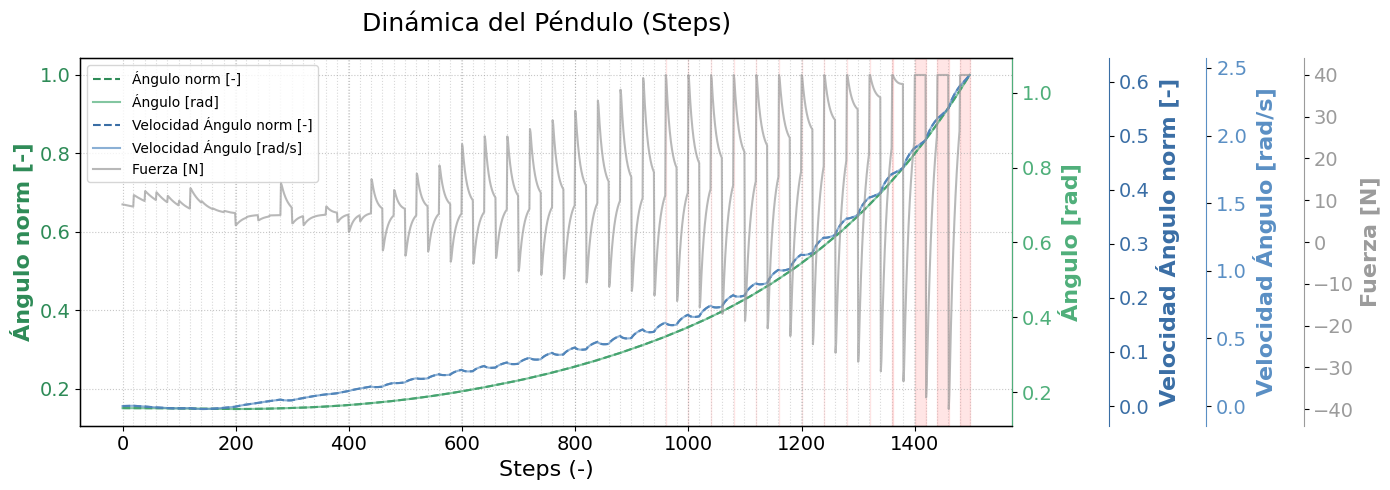

In [31]:
# --- CONFIGURACIÓN CELDA ---
cols_to_plot = ['pendulum_angle_norm', 'pendulum_angle_raw', 'pendulum_velocity_norm', 'pendulum_velocity_raw', 'cart_force']
col_names    = ['Ángulo norm [-]', 'Ángulo [rad]', 'Velocidad Ángulo norm [-]', 'Velocidad Ángulo [rad/s]', 'Fuerza [N]']

# Verde sobrio + Azul sobrio
colors = ['#2E8B57', '#4FAF7A', '#3A6EA5', '#5A8FC4', '#9b9b9b']
styles = ['--', '-', '--', '-', '-']
alphas  = [1.0, 0.7, 1.0, 0.7, 0.7]
title  = "Dinámica del Péndulo (Steps)"

# --- LLAMADA ---
plot_many_columns(step_df, cols_to_plot, colors, styles, alphas, col_names=col_names, title=title)

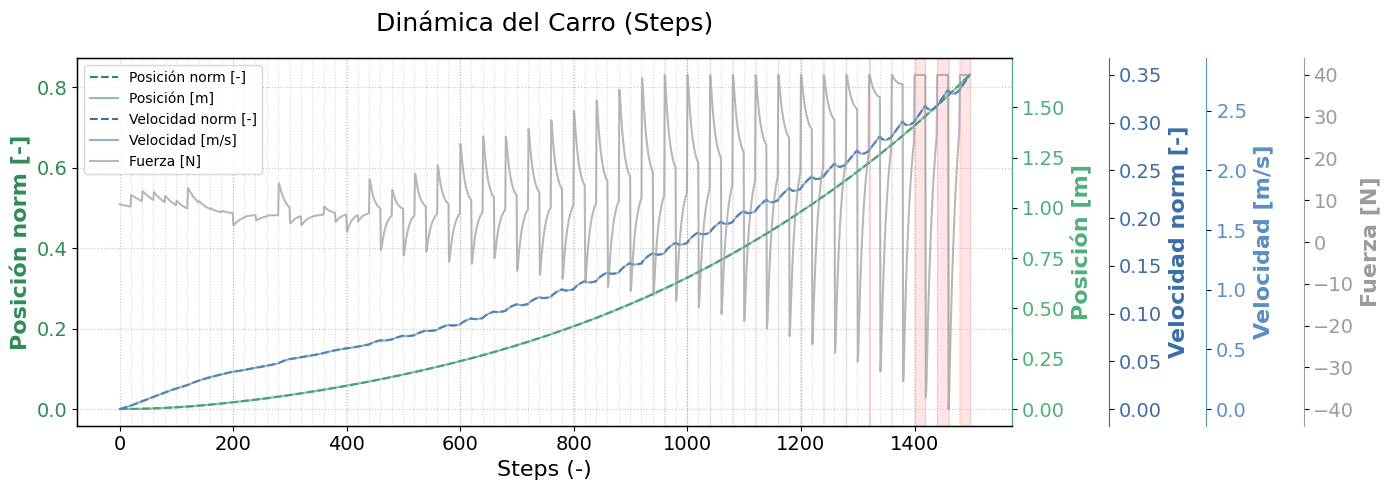

In [32]:
# --- CONFIGURACIÓN CELDA ---
cols_to_plot = ['cart_position_norm', 'cart_position_raw', 'cart_velocity_norm', 'cart_velocity_raw', 'cart_force']
col_names = ['Posición norm [-]', 'Posición [m]', 'Velocidad norm [-]', 'Velocidad [m/s]', 'Fuerza [N]']

# Verde sobrio + Azul sobrio
colors = ['#2E8B57', '#4FAF7A', '#3A6EA5', '#5A8FC4', '#9b9b9b']
styles = ['--', '-', '--', '-', '-']
alphas = [1.0, 0.7, 1.0, 0.7, 0.7]
title  = "Dinámica del Carro (Steps)"

# --- LLAMADA ---
plot_many_columns(step_df, cols_to_plot, colors, styles, alphas, col_names=col_names, title=title)

### Sanity check: Controller Data

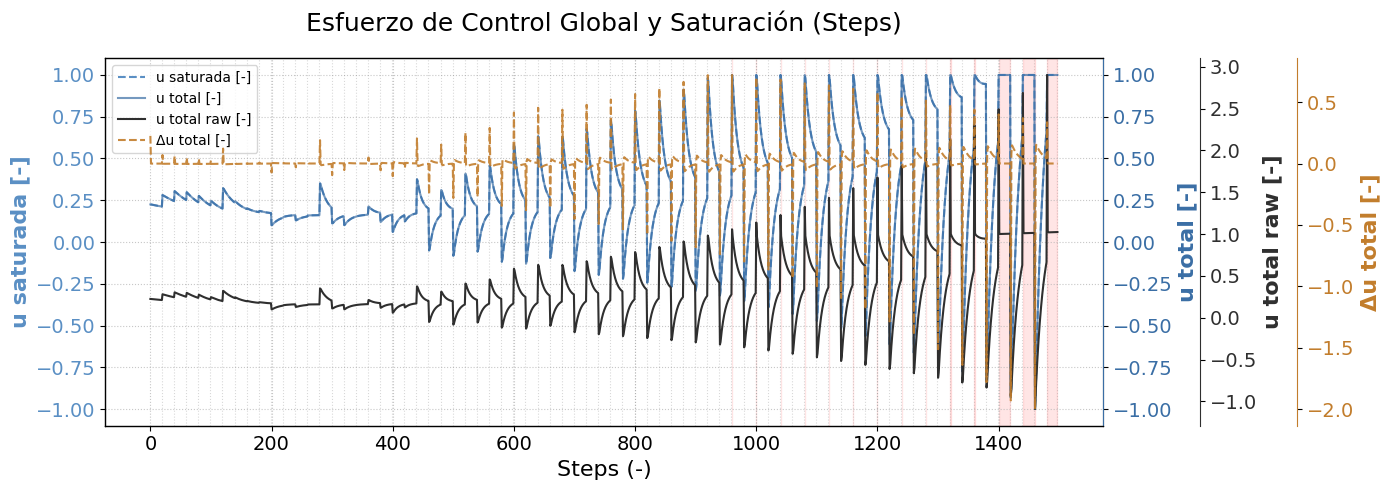

In [33]:
# --- CONFIGURACIÓN CELDA ---
cols_to_plot = ['u_total_saturated', 'u_total', 'u_total_raw', 'delta_u_total']

col_names = ['u saturada [-]', 'u total [-]', 'u total raw [-]', 'Δu total [-]']

colors = ['#5A8FC4', '#3A6EA5', '#2F2F2F', '#C27D2C']
styles = ['--', '-', '-', '--']
alphas  = [1.0, 0.7, 1.0, 0.9]
title  = "Esfuerzo de Control Global y Saturación (Steps)"

# --- LLAMADA ---
plot_many_columns(step_df, cols_to_plot, colors, styles, alphas, col_names=col_names, title=title)

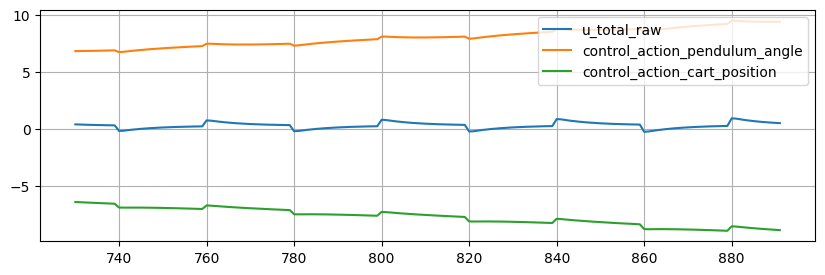

In [34]:
step_df.loc[730:891, 'u_total_raw'].plot()
step_df.loc[730:891, 'control_action_pendulum_angle'].plot()
step_df.loc[730:891, 'control_action_cart_position'].plot(figsize=(10, 3), grid=True)

plt.legend()

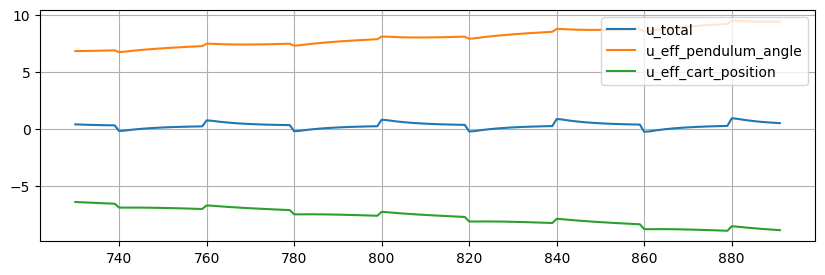

In [35]:
step_df.loc[730:891, 'u_total'].plot()
step_df.loc[730:891, 'u_eff_pendulum_angle'].plot()
step_df.loc[730:891, 'u_eff_cart_position'].plot(figsize=(10, 3), grid=True)

plt.legend()

In [ ]:
PIPE = {
    "Pendulum": {
        "gains":   ["kp_pendulum_angle", "ki_pendulum_angle", "kd_pendulum_angle"],
        "errors":  ["error_pendulum_angle", "derivative_error_pendulum_angle", "integral_error_pendulum_angle"],
        "u":       ["control_action_pendulum_angle", "delta_control_action_pendulum_angle",
                    "u_eff_pendulum_angle", "delta_u_eff_pendulum_angle"],
        "raw":     ["pendulum_angle_raw", "pendulum_velocity_raw"],
    },
    "Cart": {
        "gains":   ["kp_cart_position", "ki_cart_position", "kd_cart_position"],
        "errors":  ["error_cart_position", "derivative_error_cart_position", "integral_error_cart_position"],
        "u":       ["control_action_cart_position", "delta_control_action_cart_position",
                    "u_eff_cart_position", "delta_u_eff_cart_position"],
        "raw":     ["cart_position_raw", "cart_velocity_raw"],
    }
}

def plot_cols(df, cols, title="Plot", x_col=None, figsize=(14, 4)):
    x = df[x_col].to_numpy() if x_col and x_col in df.columns else np.arange(len(df))
    y_cols = [c for c in cols if c in df.columns]

    if not y_cols:
        return

    ax = df.plot(x=x_col if (x_col and x_col in df.columns) else None,
                 y=y_cols, figsize=figsize, title=title, grid=True)

    ax.set_xlabel(x_col if (x_col and x_col in df.columns) else "Index")
    plt.tight_layout()
    plt.show()
    
def cols_exist(df, cols): 
    return [c for c in cols if c in df.columns]

# --- 1) Vista “forense” de una ventana (elige idx) ---
def view_window(df, i, w=5, cols=None):
    a = max(0, i - w); b = min(len(df) - 1, i + w)
    return df.loc[a:b, cols] if cols else df.loc[a:b]

# --- 2) Plot secuencial por bloques (raw -> errors -> gains -> u) ---
def plot_pipeline(df, pipe, title_prefix="Pipeline", x_col=None):
    for block_name in ["raw", "errors", "gains", "u"]:
        cols = cols_exist(df, pipe.get(block_name, []))
        if cols:
            plot_walk(df, cols, x_col=x_col)  # usa tu plot_walk anterior

# --- 3) “Event-driven”: salta a puntos relevantes (saturación / grandes cambios de u) ---
def find_events(df, u_col, sat_col="is_saturated_global",
                top_du=20, min_gap=50):
    idx = set()

    if sat_col in df.columns:
        idx |= set(df.index[df[sat_col].astype(bool)])

    if u_col in df.columns:
        du = df[u_col].diff().abs()
        idx |= set(du.nlargest(top_du).index)

    idx = sorted(idx)
    # compacta para no mostrar puntos pegados
    out = []
    last = -10**9
    for i in idx:
        if i - last >= min_gap:
            out.append(i); last = i
    return out

# --- 4) Runner: para cada evento, muestra tabla + plots por bloque ---
def forensic_control_flow(df, pipe, events, w=5, x_col=None):
    # columnas que miras en tabla
    table_cols = cols_exist(df, sum([pipe.get(k, []) for k in ["raw","errors","gains","u"]], []))

    for i in events:
        print(f"\n--- EVENT @ step {i} ---")
        display(view_window(df, i, w=w, cols=table_cols))  # en notebook

        for block, cols in [("raw", pipe.get("raw", [])),
                            ("errors", pipe.get("errors", [])),
                            ("gains", pipe.get("gains", [])),
                            ("u", pipe.get("u", []))]:
            cols = cols_exist(df, cols)
            if cols:
                plot_cols(df.loc[max(0,i-w):min(len(df)-1,i+w), :], cols,
                          title=f"{block.upper()} (step {i} ± {w})",
                          x_col=x_col)

# --- 5) Uso (Péndulo) ---
p = PIPE["Pendulum"]

events = find_events(step_df,
                     u_col="u_eff_pendulum_angle" if "u_eff_pendulum_angle" in step_df.columns else "control_action_pendulum_angle",
                     sat_col="is_saturated_global",
                     top_du=25,
                     min_gap=80)

forensic_control_flow(step_df, p, events, w=10, x_col=None)

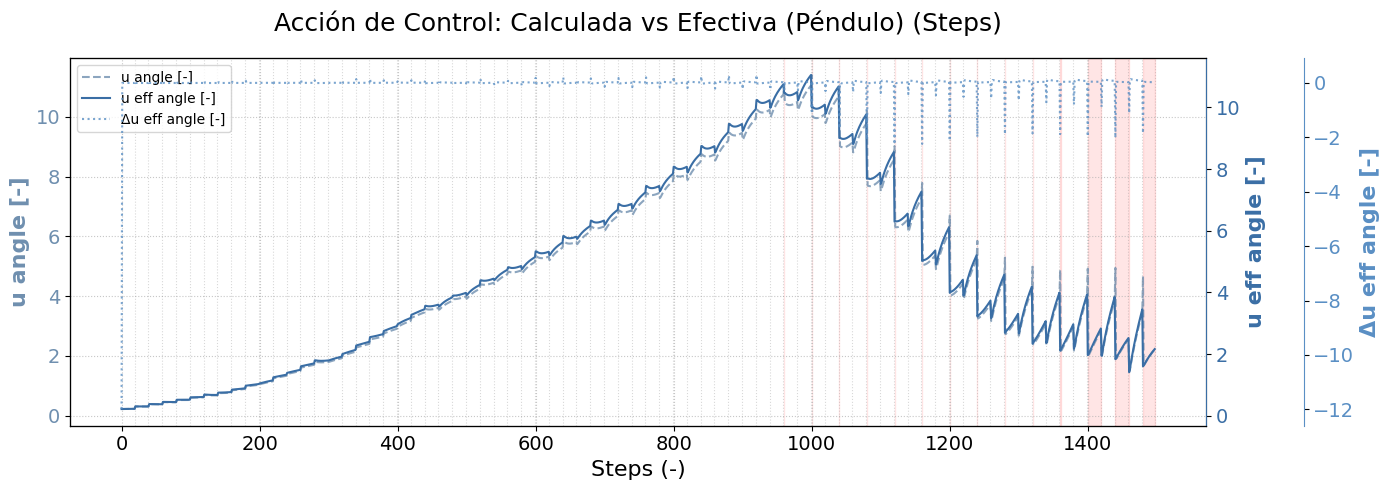

In [36]:
# --- CONFIGURACIÓN CELDA ---
cols_to_plot = ['control_action_pendulum_angle', 'u_eff_pendulum_angle', 'delta_u_eff_pendulum_angle']

col_names = ['u angle [-]','u eff angle [-]', 'Δu eff angle [-]']

colors = ['#6F8FAF', '#3A6EA5', '#5A8FC4']
styles = ['--', '-', ':']
alphas  = [0.8, 1.0, 0.8]
title  = "Acción de Control: Calculada vs Efectiva (Péndulo) (Steps)"

# --- LLAMADA ---
plot_many_columns(step_df, cols_to_plot, colors, styles, alphas, col_names=col_names, title=title)

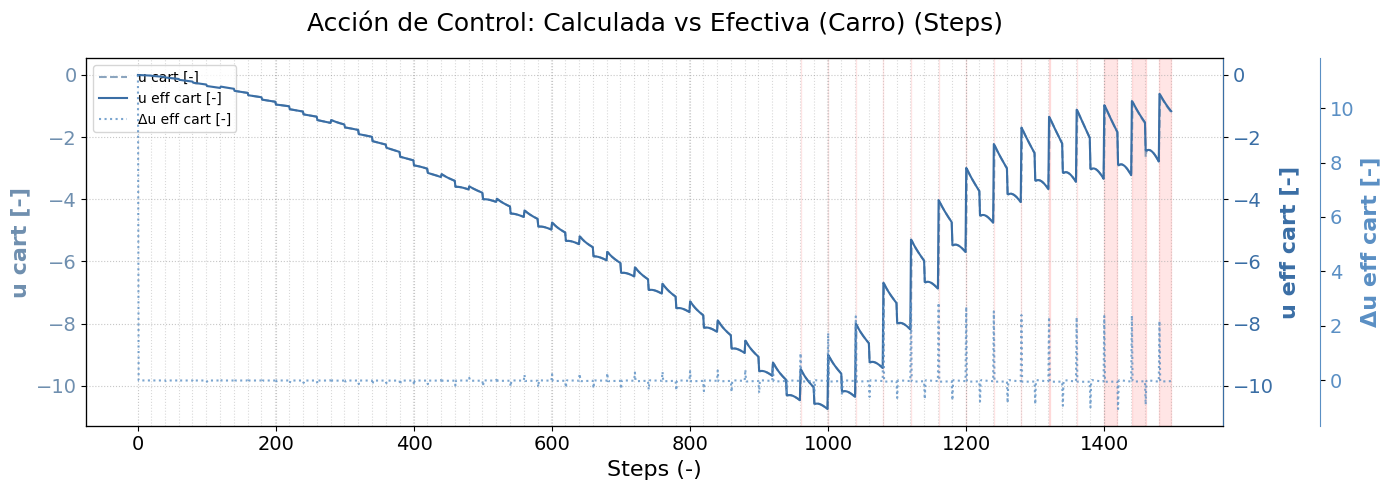

In [37]:
# --- CONFIGURACIÓN CELDA ---
cols_to_plot = ['control_action_cart_position', 'u_eff_cart_position', 'delta_u_eff_cart_position']

col_names = ['u cart [-]', 'u eff cart [-]', 'Δu eff cart [-]']

colors = ['#6F8FAF', '#3A6EA5', '#5A8FC4']
styles = ['--', '-', ':']
alphas  = [0.8, 1.0, 0.8]
title  = "Acción de Control: Calculada vs Efectiva (Carro) (Steps)"

# --- LLAMADA ---
plot_many_columns(step_df, cols_to_plot, colors, styles, alphas, col_names=col_names, title=title)

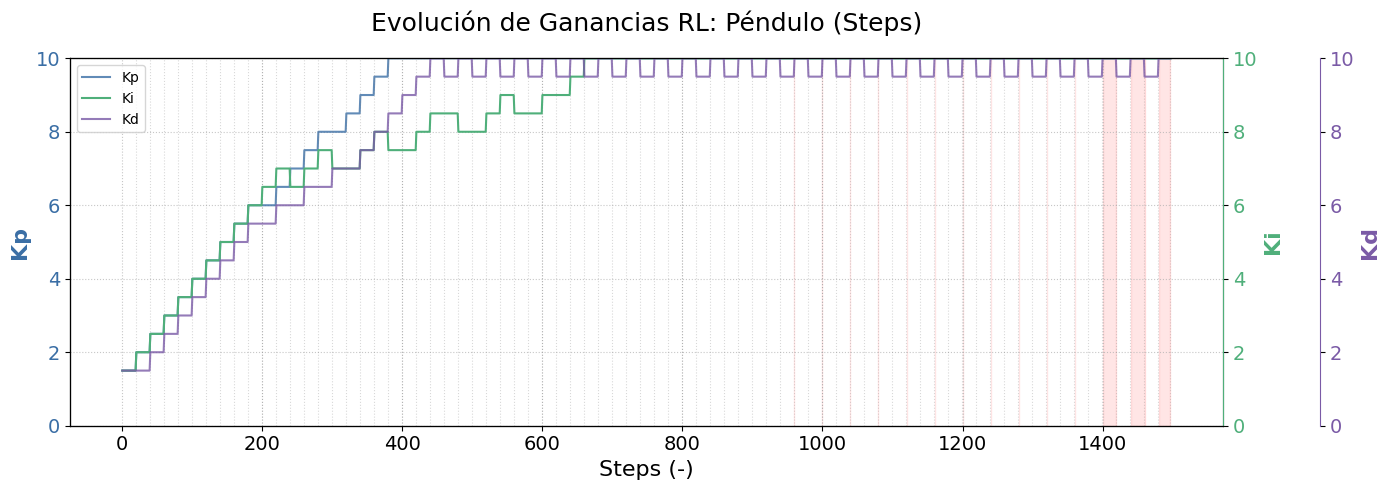

In [39]:
# --- CONFIGURACIÓN CELDA ---
cols_to_plot = ['kp_pendulum_angle', 'ki_pendulum_angle', 'kd_pendulum_angle']
col_names    = ['Kp', 'Ki', 'Kd']

colors = ['#3A6EA5', '#4FAF7A', '#7A5AA6']
styles = ['-', '-', '-']
alpha  = [0.95, 0.95, 0.95]
title  = "Evolución de Ganancias RL: Péndulo (Steps)"

# --- LLAMADA ---
plot_many_columns(step_df, cols_to_plot, colors, styles, alphas, col_names=col_names, title=title, y_lim=[0, 10])

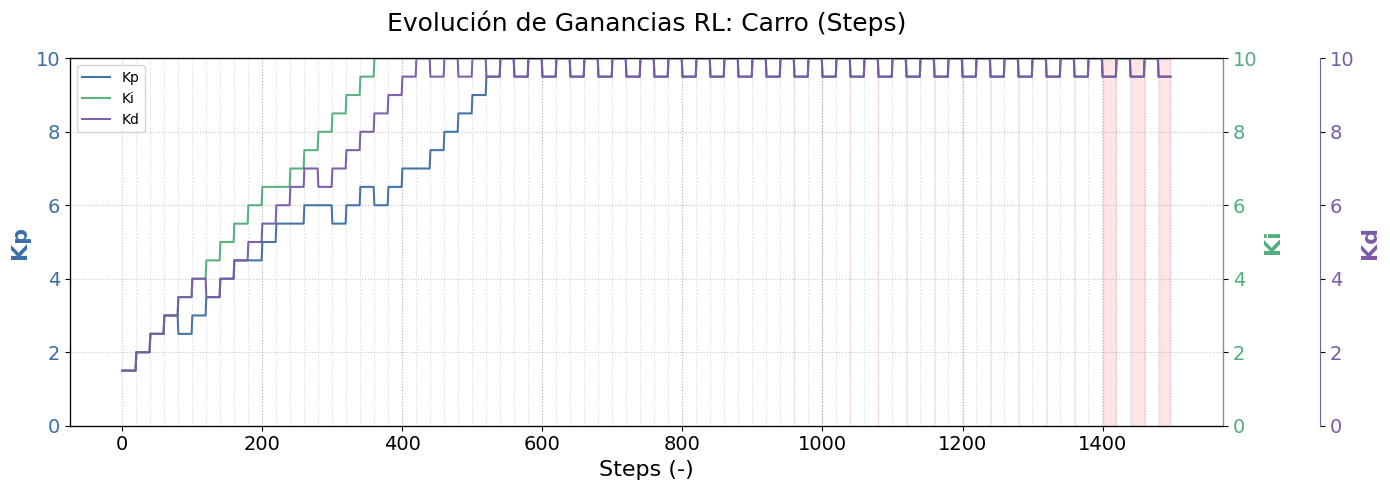

In [40]:
# --- CONFIGURACIÓN CELDA ---
cols_to_plot = ['kp_cart_position', 'ki_cart_position', 'kd_cart_position']
col_names    = ['Kp', 'Ki', 'Kd']

colors = ['#3A6EA5', '#4FAF7A', '#7A5AA6']
styles = ['-', '-', '-']
alphas  = [0.95, 0.95, 0.95]
title  = "Evolución de Ganancias RL: Carro (Steps)"

# --- LLAMADA ---
plot_many_columns(step_df, cols_to_plot, colors, styles, alphas, col_names=col_names, title=title, y_lim=[0, 10])

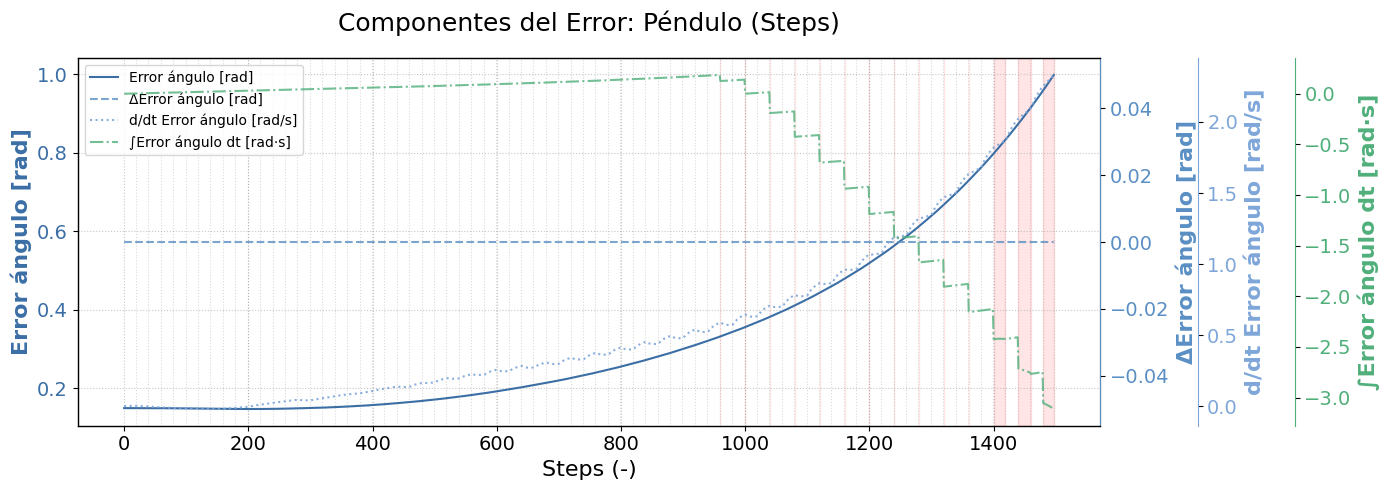

In [41]:
# --- CONFIGURACIÓN CELDA ---
cols_to_plot = ['error_pendulum_angle', 'delta_error_pendulum_angle', 
                'derivative_error_pendulum_angle', 'integral_error_pendulum_angle']
col_names = ['Error ángulo [rad]', 'ΔError ángulo [rad]','d/dt Error ángulo [rad/s]', '∫Error ángulo dt [rad·s]']

colors = ['#3A6EA5', '#5A8FC4', '#7FA6D9', '#4FAF7A']
styles = ['-', '--', ':', '-.']
alphas  = [1.0, 0.8, 0.9, 0.8]
title  = "Componentes del Error: Péndulo (Steps)"

# --- LLAMADA ---
plot_many_columns(step_df, cols_to_plot, colors, styles, alphas, col_names=col_names, title=title)

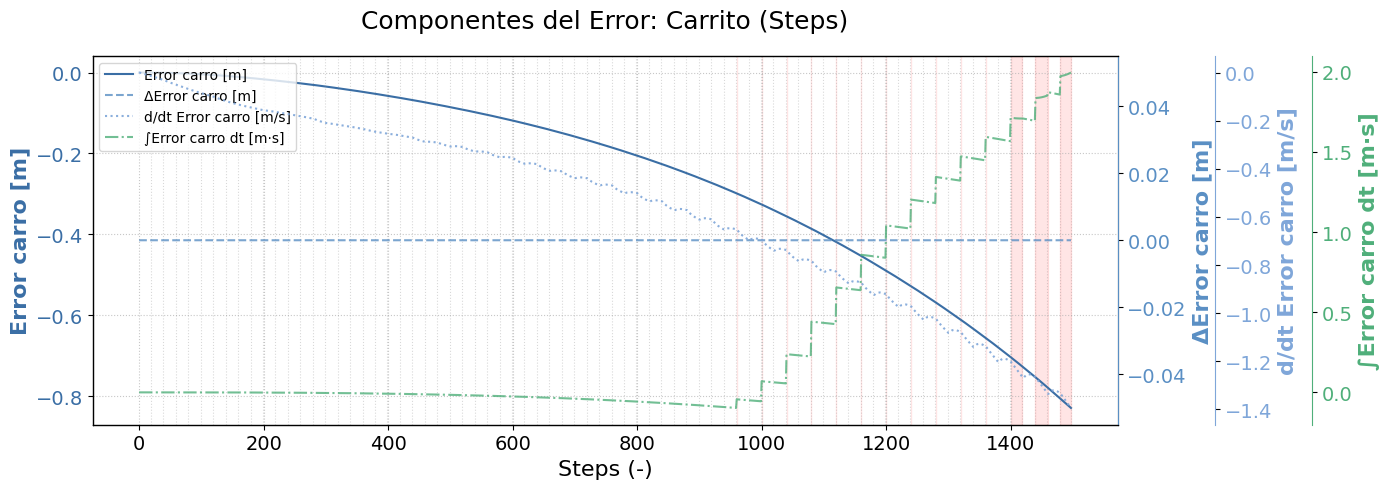

In [42]:
# --- CONFIGURACIÓN CELDA ---
cols_to_plot = ['error_cart_position',
                'delta_error_cart_position',
                'derivative_error_cart_position',
                'integral_error_cart_position']

col_names = ['Error carro [m]', 'ΔError carro [m]',
             'd/dt Error carro [m/s]', '∫Error carro dt [m·s]']

colors = ['#3A6EA5', '#5A8FC4', '#7FA6D9', '#4FAF7A']
styles = ['-', '--', ':', '-.']
alphas  = [1.0, 0.8, 0.9, 0.8]
title  = "Componentes del Error: Carrito (Steps)"

# --- LLAMADA ---
plot_many_columns(step_df, cols_to_plot, colors, styles, alphas, col_names=col_names, title=title)

### Sanity check: Reward Data

In [ ]:
y_cols_cart = ['L_e_cart_position', 'L_edot_cart_position', 'L_delta_u_cart_position', 'reward_kp_cart_position']

x = interval_timeline_df['interval_id'].to_numpy()
ax = interval_timeline_df.plot(x='interval_id', y=y_cols_cart, figsize=(10, 3), grid=True)

ax.set_xlabel('Interval')
ax.set_title('Reward Components - Cart Position')
plt.tight_layout()
plt.show()

In [ ]:
# Recompensa global por intervalo
ax = interval_timeline_df.plot(x='interval_id', y='global_interval_reward', figsize=(10, 3), grid=True, color='purple')
ax.set_xlabel('Interval')
ax.set_title('Global Interval Reward')
plt.tight_layout()
plt.show()

## Caja 7 - Análisis de Episodios (Global)
- Extraemos las métricas finales (`end_episode_data`) de todos los episodios iterando sobre los chunks encontrados.
- Generamos un DataFrame global para ver la evolución del entrenamiento y del Reward.

In [ ]:
# Cargar un resumen de todos los episodios
global_records = []

for cf in chunk_files:
    try:
        chunk_data = load_json(cf)
        for ep in chunk_data:
            ep_id = extract_episode_id(ep)
            end_data = ep.get('end_episode_data', {})
            
            record = {'episode_id': ep_id}
            if end_data:
                record.update(end_data)
            
            global_records.append(record)
    except Exception as e:
        print(f"Error cargando {cf}: {e}")

global_df = pd.DataFrame(global_records).sort_values('episode_id').reset_index(drop=True)
print(f"Total episodios cargados: {len(global_df)}")
global_df.head()

In [ ]:
# Gráfico de evolución del Total Reward a lo largo de los episodios
fig, ax1 = plt.subplots(figsize=(12, 4))

ax1.plot(global_df['episode_id'], global_df['total_reward'], color='tab:blue', alpha=0.6, label='Total Reward')
ax1.set_xlabel('Episode ID')
ax1.set_ylabel('Total Reward', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

# Epsilon en otro eje Y, si está presente
if 'epsilon' in global_df.columns:
    ax2 = ax1.twinx()
    ax2.plot(global_df['episode_id'], global_df['epsilon'], color='tab:orange', linewidth=2, label='Epsilon')
    ax2.set_ylabel('Epsilon', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Evolución del Reward Total y Epsilon por Episodio')
fig.tight_layout()
plt.show()

In [ ]:
# Razón de terminación de los episodios (estadísticas)
if 'end_termination_reason' in global_df.columns:
    term_counts = global_df['end_termination_reason'].value_counts()
    print("Razones de terminación de episodio:")
    print(term_counts)
    
    # Gráfico de torta
    term_counts.plot.pie(autopct='%1.1f%%', figsize=(5,5))
    plt.title('Termination Reasons')
    plt.ylabel('')
    plt.show()